<!-- Cell purpose: Introduce the SHG unembryonated egg analysis notebook. -->

# SHG Unembryonated Egg Analysis (`analysis_SHG.ipynb`)

This notebook follows the same analysis workflow used for 800nm, adapted to SHG datasets with pooled controls.

Rules applied:
- Pooled controls: `2024-03-04`, `2024-03-20`, `2025-06-12`
- Exclude `degenerated` eggs
- Include `arrested` and `leak` eggs up to the last recorded stage time
- Candidate SHG datasets checked here: `400-SHG-10mW-2s` and `400-SHG-10mW-5s`


In [1]:
# List the SHG candidate groups to verify

from pathlib import Path
import re

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from scipy import stats

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

sns.set_theme(style="whitegrid", context="talk")

CSV_PATH = "master_csv/01_master_unembryonated.csv"
CONTROL_DATES = [
    pd.Timestamp("2024-03-04"),
    pd.Timestamp("2024-03-20"),
    pd.Timestamp("2025-06-12"),
]

SHG_CANDIDATES = [
    {"label": "shg_10mW_2s", "wl_nm": 400, "regime": "shg", "power_mW": 10, "exposure_s": 2},
    {"label": "shg_10mW_5s", "wl_nm": 400, "regime": "shg", "power_mW": 10, "exposure_s": 5},
]

VALID_OUTCOMES = {"l3_reached", "arrested", "leak"}
MIN_NON_NULL_STAGE_ROWS = 5

PLOTS_DIR = Path("400nm/unembryonated/plots/")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR = Path("400nm/unembryonated/tables/")
TABLES_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
# Define helper functions for file lookup and data preparation

def resolve_csv_path(raw_path: str) -> Path:
    raw = Path(raw_path)
    stripped = Path(str(raw_path).replace("LIA-STH-Repo/", "", 1))

    start = Path.cwd().resolve()
    search_bases = [start, *start.parents]

    candidates = [raw, stripped]
    for base in search_bases:
        candidates.append(base / raw)
        candidates.append(base / stripped)

    seen = set()
    for cand in candidates:
        key = str(cand)
        if key in seen:
            continue
        seen.add(key)
        if cand.exists():
            return cand.resolve()

    raise FileNotFoundError(f"CSV not found. Tried: {[str(c) for c in candidates]}")


def to_snake_or_nan(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    s = re.sub(r"[^0-9a-zA-Z]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s if s else np.nan


In [3]:
# Load and clean source table

csv_file = resolve_csv_path(CSV_PATH)
df = pd.read_csv(csv_file)

unnamed = [c for c in df.columns if c.lower().startswith("unnamed")]
if unnamed:
    df = df.drop(columns=unnamed)

if "well_#" in df.columns:
    df = df.rename(columns={"well_#": "well_id"})

text_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
for col in text_cols:
    s = df[col].astype("string").str.strip()
    s = s.replace({"NA": pd.NA, "na": pd.NA, "": pd.NA, "None": pd.NA, "none": pd.NA}, regex=False)
    df[col] = s

df["start_date"] = pd.to_datetime(df["start_date"], errors="coerce")
for col in ["system", "regime", "outcome", "flags"]:
    df[col] = df[col].map(to_snake_or_nan)

for col in ["control", "wl_nm", "power_mW", "exposure_s", "t_start_h", "t_2c_h", "t_4c_h", "t_bean_h", "t_move_h"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"Loaded: {csv_file}")
print(f"Rows: {len(df)}")


Loaded: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/master_csv/01_master_unembryonated.csv
Rows: 866


In [4]:
# Candidate SHG dataset check (data availability + stage-time coverage)

shg_base = df[(df["wl_nm"] == 400) & (df["regime"] == "shg")].copy()

rows = []
for cfg in SHG_CANDIDATES:
    mask = (
        (shg_base["power_mW"] == cfg["power_mW"])
        & (shg_base["exposure_s"] == cfg["exposure_s"])
    )
    sub = shg_base[mask].copy()
    n_total = len(sub)

    sub_valid = sub[sub["outcome"].isin(VALID_OUTCOMES)].copy()
    n_valid = len(sub_valid)

    stage_cols = ["t_2c_h", "t_4c_h", "t_bean_h", "t_move_h"]
    stage_non_null = {c: int(sub_valid[c].notna().sum()) for c in stage_cols}
    n_any_stage = int(sub_valid[stage_cols].notna().any(axis=1).sum())

    include = n_any_stage >= MIN_NON_NULL_STAGE_ROWS

    rows.append(
        {
            "label": cfg["label"],
            "wl_nm": cfg["wl_nm"],
            "regime": cfg["regime"],
            "power_mW": cfg["power_mW"],
            "exposure_s": cfg["exposure_s"],
            "n_total": n_total,
            "n_valid_non_degenerated": n_valid,
            "n_any_stage_time": n_any_stage,
            "n_t_2c": stage_non_null["t_2c_h"],
            "n_t_4c": stage_non_null["t_4c_h"],
            "n_t_bean": stage_non_null["t_bean_h"],
            "n_t_move": stage_non_null["t_move_h"],
            "include_in_analysis": bool(include),
        }
    )

shg_candidate_profile_df = pd.DataFrame(rows)
display(shg_candidate_profile_df)

out_csv = TABLES_DIR / "shg_candidate_profile.csv"
shg_candidate_profile_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")

selected_shg_configs = [
    cfg for cfg in SHG_CANDIDATES
    if bool(shg_candidate_profile_df.loc[shg_candidate_profile_df["label"] == cfg["label"], "include_in_analysis"].iloc[0])
]
selected_shg_labels = [cfg["label"] for cfg in selected_shg_configs]
print("Selected SHG datasets:", selected_shg_labels)
if not selected_shg_configs:
    raise ValueError("No SHG candidate passed stage-time minimum threshold.")


,label,wl_nm,regime,power_mW,exposure_s,n_total,n_valid_non_degenerated,n_any_stage_time,n_t_2c,n_t_4c,n_t_bean,n_t_move,include_in_analysis
0,shg_10mW_2s,400,shg,10,2,36,35,21,21,18,17,16,True
1,shg_10mW_5s,400,shg,10,5,37,37,0,0,0,0,0,False


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/400nm/unembryonated/tables/shg_candidate_profile.csv
Selected SHG datasets: ['shg_10mW_2s']


In [5]:
# Build stage-time analysis table for selected SHG datasets + pooled controls

stage_label_map = {
    "dt_2c": "2-cell",
    "dt_4c": "4-cell",
    "dt_bean": "Bean",
    "dt_move": "Motion",
}
stage_order = ["2-cell", "4-cell", "Bean", "Motion"]

frames = []
for cfg in selected_shg_configs:
    sub = df[
        (df["wl_nm"] == cfg["wl_nm"])
        & (df["regime"] == cfg["regime"])
        & (df["power_mW"] == cfg["power_mW"])
        & (df["exposure_s"] == cfg["exposure_s"])
        & (df["outcome"].isin(VALID_OUTCOMES))
    ].copy()
    sub["group"] = cfg["label"]
    sub["duration_label"] = f"{int(cfg['exposure_s'])}s"
    frames.append(sub)

ctrl = df[
    (df["control"] == 1)
    & (df["start_date"].isin(CONTROL_DATES))
    & (df["outcome"].isin(VALID_OUTCOMES))
].copy()
ctrl["group"] = "pooled_control"
ctrl["duration_label"] = "control"
frames.append(ctrl)

shg_stage_df = pd.concat(frames, ignore_index=True)
for s in ["2c", "4c", "bean", "move"]:
    shg_stage_df[f"dt_{s}"] = shg_stage_df[f"t_{s}_h"] - shg_stage_df["t_start_h"]

shg_stage_long_df = (
    shg_stage_df.melt(
        id_vars=["egg_uid", "well_id", "start_date", "outcome", "group", "duration_label"],
        value_vars=["dt_2c", "dt_4c", "dt_bean", "dt_move"],
        var_name="stage",
        value_name="dt_h",
    )
    .dropna(subset=["dt_h"])
    .copy()
)
shg_stage_long_df["stage"] = shg_stage_long_df["stage"].map(stage_label_map)
shg_stage_long_df["stage"] = pd.Categorical(shg_stage_long_df["stage"], categories=stage_order, ordered=True)

display(shg_stage_long_df.head())

out_csv = TABLES_DIR / "shg_stage_times_long_selected_and_pooled_control.csv"
shg_stage_long_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")


,egg_uid,well_id,start_date,outcome,group,duration_label,stage,dt_h
0,347,1,2024-06-19,arrested,shg_10mW_2s,2s,2-cell,209.5
1,348,1,2024-06-19,l3_reached,shg_10mW_2s,2s,2-cell,68.5
3,351,2,2024-06-19,l3_reached,shg_10mW_2s,2s,2-cell,61.5
4,352,2,2024-06-19,l3_reached,shg_10mW_2s,2s,2-cell,37.5
5,353,3,2024-06-19,l3_reached,shg_10mW_2s,2s,2-cell,256.5


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/400nm/unembryonated/tables/shg_stage_times_long_selected_and_pooled_control.csv


Figure: Vertical raincloud comparison of embryonation-stage timing across selected SHG datasets and pooled controls. Panels show each selected SHG dataset plus pooled controls (control dates: 2024-03-04, 2024-03-20, 2025-06-12), with a shared x-axis for direct comparison. The x-axis is elapsed time in hours from incubation start, computed per stage as dt_stage = t_stage_h - t_start_h; the y-axis shows developmental stage (2-cell, 4-cell, Bean, Motion). Each raincloud combines distribution shape (half-violin), spread and central tendency (box/IQR), and individual observations, with bold labels indicating stage-specific medians. Included eggs are restricted to VALID_OUTCOMES (non-degenerated outcomes defined earlier); stage-wise sample sizes can differ because missing stage timestamps are excluded.


/Users/arkadi/Desktop/lia-sth/.venv/lib/python3.11/site-packages/ptitprince/PtitPrince.py:154: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_name, group_df in self.plot_data.groupby(grouping_vars):
/Users/arkadi/Desktop/lia-sth/.venv/lib/python3.11/site-packages/ptitprince/PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/Users/arkadi/Desktop/lia-sth/.venv/lib/python3.11/site-packages/ptitprince/PtitPrince.py:154: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default a

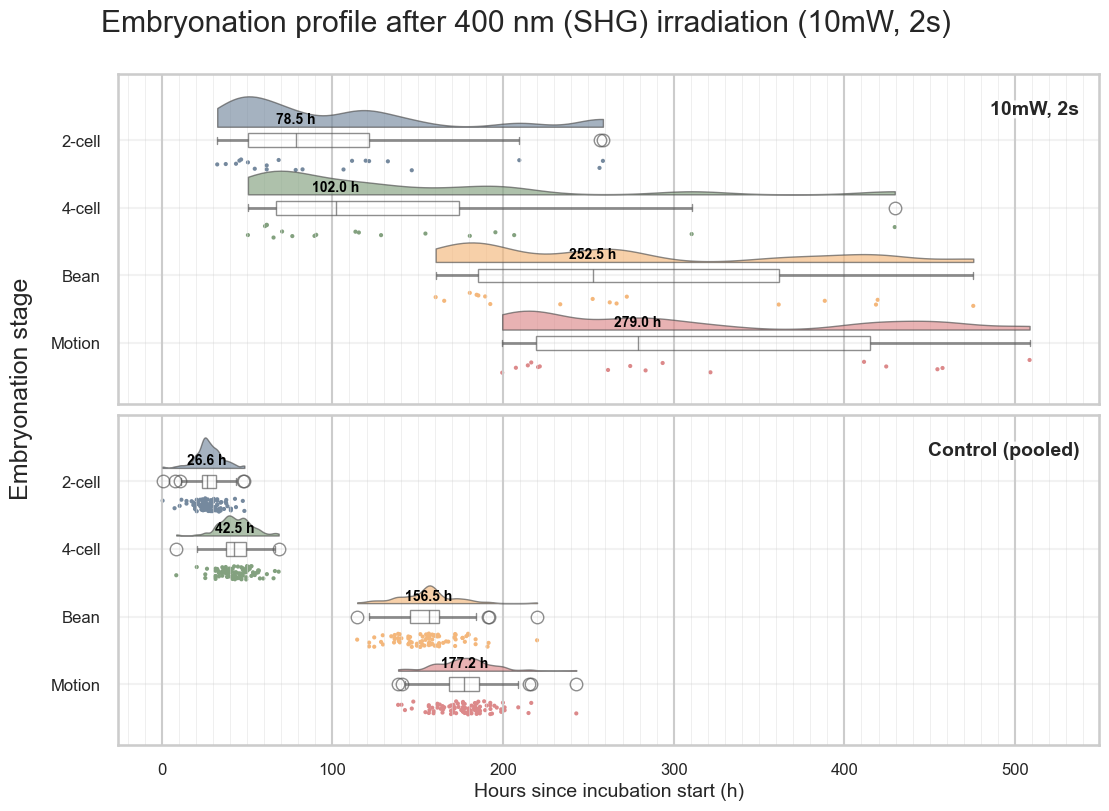

Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/400nm/unembryonated/plots/raincloud_shg_stage_timing_selected_vs_pooled_control.png


In [6]:
# Vertical raincloud comparison of embryonation-stage timing across selected SHG datasets and pooled controls

fig_caption_shg_raincloud = (
    "Figure: Vertical raincloud comparison of embryonation-stage timing across selected SHG datasets and pooled controls. "
    "Panels show each selected SHG dataset plus pooled controls (control dates: 2024-03-04, 2024-03-20, 2025-06-12), "
    "with a shared x-axis for direct comparison. The x-axis is elapsed time in hours from incubation start, computed "
    "per stage as dt_stage = t_stage_h - t_start_h; the y-axis shows developmental stage (2-cell, 4-cell, Bean, Motion). "
    "Each raincloud combines distribution shape (half-violin), spread and central tendency (box/IQR), and individual "
    "observations, with bold labels indicating stage-specific medians. Included eggs are restricted to VALID_OUTCOMES "
    "(non-degenerated outcomes defined earlier); stage-wise sample sizes can differ because missing stage timestamps are excluded."
)
print(fig_caption_shg_raincloud)

if "shg_stage_long_df" not in globals():
    raise ValueError("Run the stage table cell first.")

try:
    import ptitprince as pt
except Exception as exc:
    raise ImportError("Install `ptitprince` to render raincloud plots.") from exc

from matplotlib.ticker import MultipleLocator

group_order = selected_shg_labels + ["pooled_control"]

def format_group_label(g: str) -> str:
    if g == "pooled_control":
        return "Control (pooled)"
    if g.startswith("shg_"):
        parts = g.split("_")
        if len(parts) >= 3:
            return f"{parts[1]}, {parts[2]}"
    return g.replace("_", " ")

group_display_map = {g: format_group_label(g) for g in group_order}

plot_df = shg_stage_long_df[shg_stage_long_df["group"].isin(group_order)].copy()
plot_df["group"] = pd.Categorical(plot_df["group"], categories=group_order, ordered=True)

stage_palette = ["#75899e", "#83a17f", "#f4b77b", "#dc898a"]
label_offset_cat = -0.20
pad_top_cat = 0.12 * len(stage_order)
pad_bottom_cat = 0.10 * len(stage_order)

fig, axes = plt.subplots(len(group_order), 1, figsize=(12, 4.4 * len(group_order)), sharex=True)
if len(group_order) == 1:
    axes = [axes]

max_dt = 0.0
for ax, grp in zip(axes, group_order):
    gdf = plot_df[plot_df["group"] == grp].copy()
    if gdf.empty:
        ax.text(0.5, 0.5, f"No data for {group_display_map[grp]}", ha="center", va="center")
        ax.set_ylabel("")
        continue

    max_dt = max(max_dt, float(gdf["dt_h"].max()))

    pt.RainCloud(
        x="stage",
        y="dt_h",
        data=gdf,
        orient="h",
        order=stage_order,
        palette=stage_palette,
        bw=0.2,
        width_viol=0.9,
        width_box=0.2,
        move=0.35,
        alpha=0.65,
        dodge=False,
        pointplot=False,
        ax=ax,
    )

    medians = gdf.groupby("stage", observed=True)["dt_h"].median().reindex(stage_order)
    for y, (_, med) in enumerate(medians.items()):
        ax.text(
            med,
            y + label_offset_cat,
            f"{med:.1f} h",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            color="black",
            zorder=6,
        )

    ax.text(
        0.98,
        0.92,
        group_display_map[grp],
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=14,
        fontweight="bold",
        bbox={
            "boxstyle": "round,pad=0.0",
            "facecolor": "white",
            "edgecolor": "#0C0C0C",
            "linewidth": 0.0,
            "alpha": 0.9,
        },
    )

    ax.set_ylabel("")
    ax.tick_params(axis="both", labelsize=12)
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    ax.xaxis.set_minor_locator(MultipleLocator(10))
    ax.grid(axis="x", which="minor", color="#e0e0e0", linewidth=0.4, alpha=0.9)
    ax.set_ylim(-0.5 - pad_top_cat, len(stage_order) - 0.5 + pad_bottom_cat)
    ax.invert_yaxis()

axes[-1].set_xlabel("Hours since incubation start (h)", fontsize=14)
for ax in axes[:-1]:
    ax.set_xlabel("")

for ax in axes:
    pad_left = max(5, 0.05 * max_dt) if max_dt > 0 else 5
    ax.set_xlim(left=-pad_left, right=max_dt * 1.08 if max_dt > 0 else None)

fig.supylabel("Embryonation stage", x=0.07, fontsize=18)
fig.suptitle("Embryonation profile after 400 nm (SHG) irradiation (10mW, 2s)", y=0.93)
fig.tight_layout(rect=[0.04, 0, 1, 0.95], h_pad=0.45)

out_png = PLOTS_DIR / "raincloud_shg_stage_timing_selected_vs_pooled_control.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png.resolve()}")


Figure: Grouped boxplot with strip overlay comparing embryonation-stage timing across selected SHG datasets and pooled controls. The x-axis is elapsed time in hours from incubation start, computed per stage as dt_stage = t_stage_h - t_start_h; the y-axis shows developmental stage (2-cell, 4-cell, Bean, Motion). Boxplots summarize subgroup distributions (median, IQR, whiskers), and jittered points show individual eggs. The legend identifies selected SHG datasets and pooled controls; pooled controls combine control dates 2024-03-04, 2024-03-20, and 2025-06-12. Included eggs are restricted to VALID_OUTCOMES (non-degenerated outcomes defined earlier), and stage-wise sample sizes can differ because missing stage timestamps are excluded after reshaping to long format.


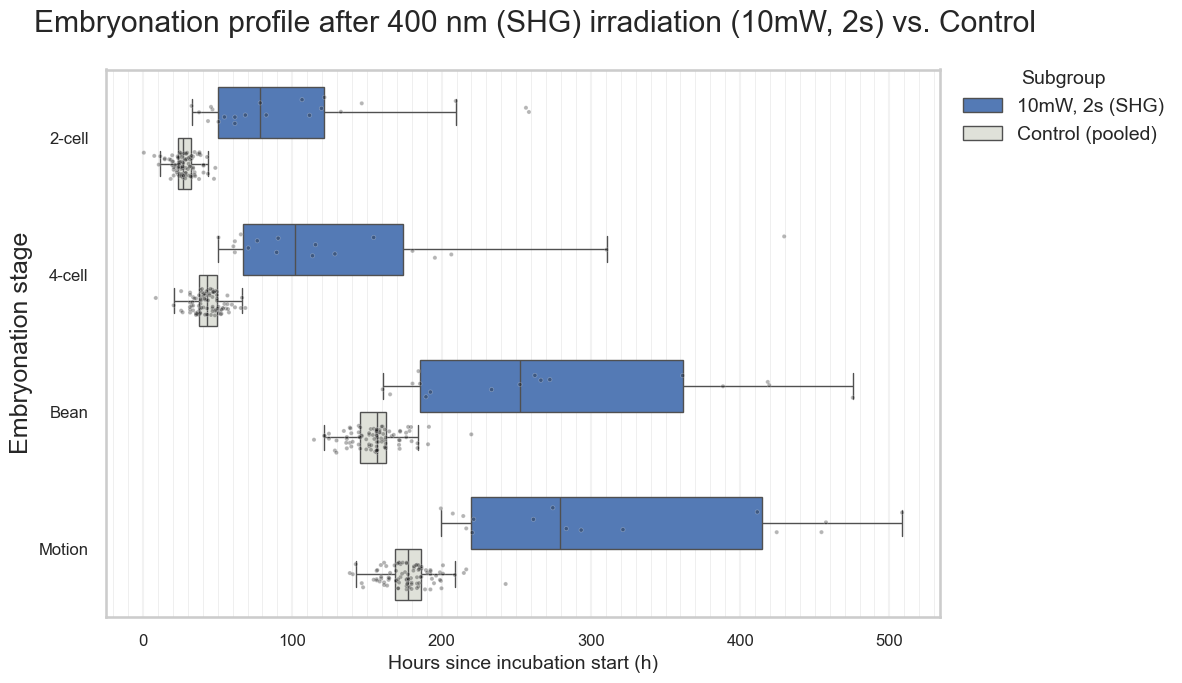

Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/400nm/unembryonated/plots/boxplot_shg_stage_timing_vs_pooled_control.png


In [7]:
# Grouped boxplot with strip overlay comparing embryonation-stage timing across selected SHG datasets and pooled controls

fig_caption_shg_stage_boxplot = (
    "Figure: Grouped boxplot with strip overlay comparing embryonation-stage timing across selected SHG datasets "
    "and pooled controls. The x-axis is elapsed time in hours from incubation start, computed per stage as "
    "dt_stage = t_stage_h - t_start_h; the y-axis shows developmental stage (2-cell, 4-cell, Bean, Motion). "
    "Boxplots summarize subgroup distributions (median, IQR, whiskers), and jittered points show individual eggs. "
    "The legend identifies selected SHG datasets and pooled controls; pooled controls combine control dates "
    "2024-03-04, 2024-03-20, and 2025-06-12. Included eggs are restricted to VALID_OUTCOMES (non-degenerated "
    "outcomes defined earlier), and stage-wise sample sizes can differ because missing stage timestamps are excluded "
    "after reshaping to long format."
)
print(fig_caption_shg_stage_boxplot)

if "shg_stage_long_df" not in globals():
    raise ValueError("Run the stage table cell first.")

group_order = selected_shg_labels + ["pooled_control"]

def format_group_label(g: str) -> str:
    if g == "pooled_control":
        return "Control (pooled)"
    if g.startswith("shg_"):
        parts = g.split("_")
        if len(parts) >= 3:
            return f"{parts[1]}, {parts[2]} (SHG)"
    return g.replace("_", " ")

group_display_map = {g: format_group_label(g) for g in group_order}

base_colors = ["#4477c5", "#e0e2d8", "#7f8c8d", "#4e79a7"]
palette = {g: base_colors[i % len(base_colors)] for i, g in enumerate(group_order)}
point_palette = {g: "#000000" if g == "pooled_control" else "#0A0A0A" for g in group_order}

plot_df = shg_stage_long_df[shg_stage_long_df["group"].isin(group_order)].copy()
plot_df["group"] = pd.Categorical(plot_df["group"], categories=group_order, ordered=True)

fig, ax = plt.subplots(figsize=(12, 7.5))
sns.boxplot(
    data=plot_df,
    x="dt_h",
    y="stage",
    hue="group",
    order=stage_order,
    hue_order=group_order,
    palette=palette,
    showfliers=False,
    linewidth=1.0,
    width=0.75,
    ax=ax,
)

sns.stripplot(
    data=plot_df,
    x="dt_h",
    y="stage",
    hue="group",
    order=stage_order,
    hue_order=group_order,
    palette=point_palette,
    dodge=True,
    jitter=0.2,
    size=3,
    alpha=0.3,
    linewidth=0.5,
    edgecolor="white",
    ax=ax,
)


ax.set_title("")
ax.set_ylabel("Embryonation stage", fontsize=18)
ax.set_xlabel("Hours since incubation start (h)", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.grid(axis="x", alpha=0.25)
ax.xaxis.set_minor_locator(MultipleLocator(10))
ax.grid(axis="x", which="minor", color="#e0e0e0", linewidth=0.4, alpha=0.9)

handles, labels = ax.get_legend_handles_labels()
seen = set()
uniq_h = []
uniq_l = []
for h, l in zip(handles, labels):
    if l in seen:
        continue
    seen.add(l)
    uniq_h.append(h)
    uniq_l.append(l)

if ax.get_legend() is not None:
    ax.get_legend().remove()

display_labels = [group_display_map.get(l, l) for l in uniq_l]
fig.legend(
    uniq_h,
    display_labels,
    title="Subgroup",
    loc="upper left",
    bbox_to_anchor=(0.85, 0.85),
    frameon=False,
    fontsize=14,
    title_fontsize=14,
    borderaxespad=0.0,
)

fig.suptitle("Embryonation profile after 400 nm (SHG) irradiation (10mW, 2s) vs. Control", y=0.92)
plt.tight_layout(rect=[0.04, 0, 0.86, 0.95])
out_png = PLOTS_DIR / "boxplot_shg_stage_timing_vs_pooled_control.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png.resolve()}")


In [8]:
# Significance across selected SHG datasets and pooled control within each stage

from itertools import combinations

alpha = 0.05
group_order = selected_shg_labels + ["pooled_control"]


def holm_adjust(pvals: np.ndarray) -> np.ndarray:
    m = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty(m, dtype=float)
    running = 0.0
    for rank, idx in enumerate(order):
        candidate = pvals[idx] * (m - rank)
        running = max(running, candidate)
        adj[idx] = min(running, 1.0)
    return adj


def p_to_sig(p: float) -> str:
    if np.isnan(p):
        return "NA"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"

rows = []
for stage in stage_order:
    sdf = shg_stage_long_df[shg_stage_long_df["stage"] == stage].copy()
    groups = [sdf.loc[sdf["group"] == g, "dt_h"].to_numpy(dtype=float) for g in group_order]
    sizes = {g: len(arr) for g, arr in zip(group_order, groups)}

    normality_p = {}
    normal_ok = True
    for g, arr in zip(group_order, groups):
        if len(arr) < 3:
            normality_p[g] = np.nan
            normal_ok = False
            continue
        p_norm = float(stats.shapiro(arr).pvalue)
        normality_p[g] = p_norm
        if p_norm < alpha:
            normal_ok = False

    if any(len(arr) == 0 for arr in groups):
        omnibus_test = "NA"
        omnibus_p = np.nan
        pair_method = "NA"
    elif normal_ok:
        omnibus_test = "ANOVA"
        omnibus_p = float(stats.f_oneway(*groups).pvalue)
        pair_method = "Welch t-test"
    else:
        omnibus_test = "Kruskal-Wallis"
        omnibus_p = float(stats.kruskal(*groups).pvalue)
        pair_method = "Mann-Whitney U"

    pair_idxs = list(combinations(range(len(group_order)), 2))
    raw_ps = []
    raw_stats = []
    pair_names = []

    for i, j in pair_idxs:
        g1, g2 = groups[i], groups[j]
        pair_names.append(f"{group_order[i]} vs {group_order[j]}")
        if len(g1) == 0 or len(g2) == 0:
            raw_stats.append(np.nan)
            raw_ps.append(np.nan)
            continue
        if pair_method == "Welch t-test":
            tst = stats.ttest_ind(g1, g2, equal_var=False, nan_policy="omit")
            raw_stats.append(float(tst.statistic))
            raw_ps.append(float(tst.pvalue))
        elif pair_method == "Mann-Whitney U":
            mw = stats.mannwhitneyu(g1, g2, alternative="two-sided")
            raw_stats.append(float(mw.statistic))
            raw_ps.append(float(mw.pvalue))
        else:
            raw_stats.append(np.nan)
            raw_ps.append(np.nan)

    raw_ps_arr = np.array(raw_ps, dtype=float)
    valid = np.isfinite(raw_ps_arr)
    adj = np.full_like(raw_ps_arr, np.nan)
    if valid.any():
        adj[valid] = holm_adjust(raw_ps_arr[valid])

    for comp, st, p_raw, p_adj in zip(pair_names, raw_stats, raw_ps, adj):
        row = {
            "stage": stage,
            "omnibus_test": omnibus_test,
            "omnibus_p": omnibus_p,
            "pairwise_test": pair_method,
            "comparison": comp,
            "statistic": st,
            "p_raw": p_raw,
            "p_holm": p_adj,
            "significant_0.05": bool(np.isfinite(p_adj) and p_adj < alpha),
            "sig": p_to_sig(p_adj),
        }
        for g in group_order:
            row[f"n_{g}"] = sizes.get(g, 0)
            row[f"normality_p_{g}"] = normality_p.get(g, np.nan)
        rows.append(row)

shg_stage_stats_df = pd.DataFrame(rows).sort_values(["stage", "comparison"]).reset_index(drop=True)
display(shg_stage_stats_df)

out_csv = TABLES_DIR / "shg_stage_significance_selected_vs_pooled_control.csv"
shg_stage_stats_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")


,stage,omnibus_test,omnibus_p,pairwise_test,comparison,statistic,p_raw,p_holm,significant_0.05,sig,n_shg_10mW_2s,normality_p_shg_10mW_2s,n_pooled_control,normality_p_pooled_control
0,2-cell,Kruskal-Wallis,6.806230e-12,Mann-Whitney U,shg_10mW_2s vs pooled_control,1915.0,6.982646e-12,6.982646e-12,True,***,21,0.002162,93,0.089128
1,4-cell,Kruskal-Wallis,1.215209e-10,Mann-Whitney U,shg_10mW_2s vs pooled_control,1641.5,1.247645e-10,1.247645e-10,True,***,18,0.000967,93,0.325852
2,Bean,Kruskal-Wallis,1.673112e-09,Mann-Whitney U,shg_10mW_2s vs pooled_control,1518.5,1.716481e-09,1.716481e-09,True,***,17,0.022102,93,0.017839
3,Motion,Kruskal-Wallis,5.050368e-10,Mann-Whitney U,shg_10mW_2s vs pooled_control,1470.0,5.189995e-10,5.189995e-10,True,***,16,0.020993,93,0.046235


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/400nm/unembryonated/tables/shg_stage_significance_selected_vs_pooled_control.csv


In [9]:
# Post-hoc summary table for significant SHG stage comparisons (from previous cell)

if "shg_stage_stats_df" not in globals():
    raise ValueError("Run the SHG stage significance cell first.")

shg_stage_posthoc_sig_df = shg_stage_stats_df[shg_stage_stats_df["significant_0.05"]].copy()
shg_stage_posthoc_sig_df = shg_stage_posthoc_sig_df.sort_values(["stage", "comparison"]).reset_index(drop=True)

display(shg_stage_posthoc_sig_df)

out_csv = TABLES_DIR / "shg_stage_posthoc_significant_rows.csv"
shg_stage_posthoc_sig_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")


,stage,omnibus_test,omnibus_p,pairwise_test,comparison,statistic,p_raw,p_holm,significant_0.05,sig,n_shg_10mW_2s,normality_p_shg_10mW_2s,n_pooled_control,normality_p_pooled_control
0,2-cell,Kruskal-Wallis,6.806230e-12,Mann-Whitney U,shg_10mW_2s vs pooled_control,1915.0,6.982646e-12,6.982646e-12,True,***,21,0.002162,93,0.089128
1,4-cell,Kruskal-Wallis,1.215209e-10,Mann-Whitney U,shg_10mW_2s vs pooled_control,1641.5,1.247645e-10,1.247645e-10,True,***,18,0.000967,93,0.325852
2,Bean,Kruskal-Wallis,1.673112e-09,Mann-Whitney U,shg_10mW_2s vs pooled_control,1518.5,1.716481e-09,1.716481e-09,True,***,17,0.022102,93,0.017839
3,Motion,Kruskal-Wallis,5.050368e-10,Mann-Whitney U,shg_10mW_2s vs pooled_control,1470.0,5.189995e-10,5.189995e-10,True,***,16,0.020993,93,0.046235


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/400nm/unembryonated/tables/shg_stage_posthoc_significant_rows.csv


In [10]:
# Time differences (hours) for significant SHG stage post-hoc comparisons

if "shg_stage_posthoc_sig_df" not in globals():
    raise ValueError("Run the SHG significant post-hoc table cell first.")

rows = []
for _, r in shg_stage_posthoc_sig_df.iterrows():
    stage = r["stage"]
    g1_name, g2_name = r["comparison"].split(" vs ")

    g1 = shg_stage_long_df[(shg_stage_long_df["stage"] == stage) & (shg_stage_long_df["group"] == g1_name)]["dt_h"].dropna().to_numpy(dtype=float)
    g2 = shg_stage_long_df[(shg_stage_long_df["stage"] == stage) & (shg_stage_long_df["group"] == g2_name)]["dt_h"].dropna().to_numpy(dtype=float)
    if len(g1) == 0 or len(g2) == 0:
        continue

    mean_g1 = float(np.mean(g1))
    mean_g2 = float(np.mean(g2))
    med_g1 = float(np.median(g1))
    med_g2 = float(np.median(g2))
    sd_g1 = float(np.std(g1, ddof=1)) if len(g1) > 1 else np.nan
    sd_g2 = float(np.std(g2, ddof=1)) if len(g2) > 1 else np.nan

    rows.append(
        {
            "stage": stage,
            "comparison": r["comparison"],
            "n_group1": int(len(g1)),
            "n_group2": int(len(g2)),
            "median_group1_h": med_g1,
            "median_group2_h": med_g2,
            "median_diff_h_(g2-g1)": med_g2 - med_g1,
            "mean_group1_h": mean_g1,
            "mean_group2_h": mean_g2,
            "mean_diff_h_(g2-g1)": mean_g2 - mean_g1,
            "sd_group1_h": sd_g1,
            "sd_group2_h": sd_g2,
            "sd_diff_indep_h": np.sqrt(sd_g1 ** 2 + sd_g2 ** 2) if np.isfinite(sd_g1) and np.isfinite(sd_g2) else np.nan,
            "p_holm": r["p_holm"],
            "sig": r["sig"],
        }
    )

shg_stage_sig_diffs_df = pd.DataFrame(rows).sort_values(["stage", "comparison"]).reset_index(drop=True)
display(shg_stage_sig_diffs_df)

out_csv = TABLES_DIR / "shg_stage_significant_time_differences.csv"
shg_stage_sig_diffs_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")


,stage,comparison,n_group1,n_group2,median_group1_h,median_group2_h,median_diff_h_(g2-g1),mean_group1_h,mean_group2_h,mean_diff_h_(g2-g1),sd_group1_h,sd_group2_h,sd_diff_indep_h,p_holm,sig
0,2-cell,shg_10mW_2s vs pooled_control,21,93,78.5,26.6,-51.9,101.214286,27.446237,-73.768049,68.022895,7.999899,68.491698,6.982646e-12,***
1,4-cell,shg_10mW_2s vs pooled_control,18,93,102.0,42.5,-59.5,136.722222,42.979570,-93.742652,99.865531,9.943280,100.359319,1.247645e-10,***
2,Bean,shg_10mW_2s vs pooled_control,17,93,252.5,156.5,-96.0,271.147059,155.286022,-115.861037,102.651072,16.935707,104.038747,1.716481e-09,***
3,Motion,shg_10mW_2s vs pooled_control,16,93,279.0,177.2,-101.8,310.687500,177.533333,-133.154167,105.383249,16.931649,106.734764,5.189995e-10,***


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/400nm/unembryonated/tables/shg_stage_significant_time_differences.csv


In [11]:
# Per-egg stage delta table for selected SHG datasets + pooled controls

if "shg_stage_df" not in globals():
    raise ValueError("Run the stage table build cell first.")

shg_delta_df = shg_stage_df.copy()
shg_delta_df["delta_2c_4c"] = shg_delta_df["t_4c_h"] - shg_delta_df["t_2c_h"]
shg_delta_df["delta_4c_bean"] = shg_delta_df["t_bean_h"] - shg_delta_df["t_4c_h"]
shg_delta_df["delta_bean_move"] = shg_delta_df["t_move_h"] - shg_delta_df["t_bean_h"]

shg_delta_df = shg_delta_df.sort_values(["group", "start_date", "well_id", "egg_uid"]).reset_index(drop=True)

delta_cols = [
    "group",
    "duration_label",
    "start_date",
    "egg_uid",
    "well_id",
    "outcome",
    "delta_2c_4c",
    "delta_4c_bean",
    "delta_bean_move",
]
shg_delta_table_df = shg_delta_df[delta_cols].copy()
display(shg_delta_table_df)

out_csv = TABLES_DIR / "shg_delta_table_selected_and_pooled_control.csv"
shg_delta_table_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")


,group,duration_label,start_date,egg_uid,well_id,outcome,delta_2c_4c,delta_4c_bean,delta_bean_move
0,pooled_control,control,2024-03-04,383,1,l3_reached,18.0,103.0,20.0
1,pooled_control,control,2024-03-04,384,1,l3_reached,18.0,109.0,22.0
2,pooled_control,control,2024-03-04,385,2,l3_reached,16.0,110.0,20.0
3,pooled_control,control,2024-03-04,386,2,l3_reached,15.0,102.0,21.0
4,pooled_control,control,2024-03-04,387,2,l3_reached,16.0,104.0,25.0
...,...,...,...,...,...,...,...,...,...
123,shg_10mW_2s,2s,2024-06-19,378,11,l3_reached,16.0,128.0,32.0
124,shg_10mW_2s,2s,2024-06-19,379,11,arrested,NaN,NaN,NaN
125,shg_10mW_2s,2s,2024-06-19,380,12,arrested,NaN,NaN,NaN
126,shg_10mW_2s,2s,2024-06-19,381,12,arrested,NaN,NaN,NaN


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/400nm/unembryonated/tables/shg_delta_table_selected_and_pooled_control.csv


Figure: Grouped boxplot with strip overlay comparing delta-stage timing across selected SHG datasets and pooled controls. The x-axis is elapsed time in hours between consecutive stages (delta_h), and the y-axis shows transition stage (2c->4c, 4c->Bean, Bean->Motion). Boxplots summarize subgroup distributions (median, IQR, whiskers), and jittered points show individual eggs. The legend identifies selected SHG datasets and pooled controls; pooled controls combine control dates 2024-03-04, 2024-03-20, and 2025-06-12. Included eggs are restricted to VALID_OUTCOMES (non-degenerated outcomes defined earlier), with transition-wise sample sizes varying due to missing stage timestamps.


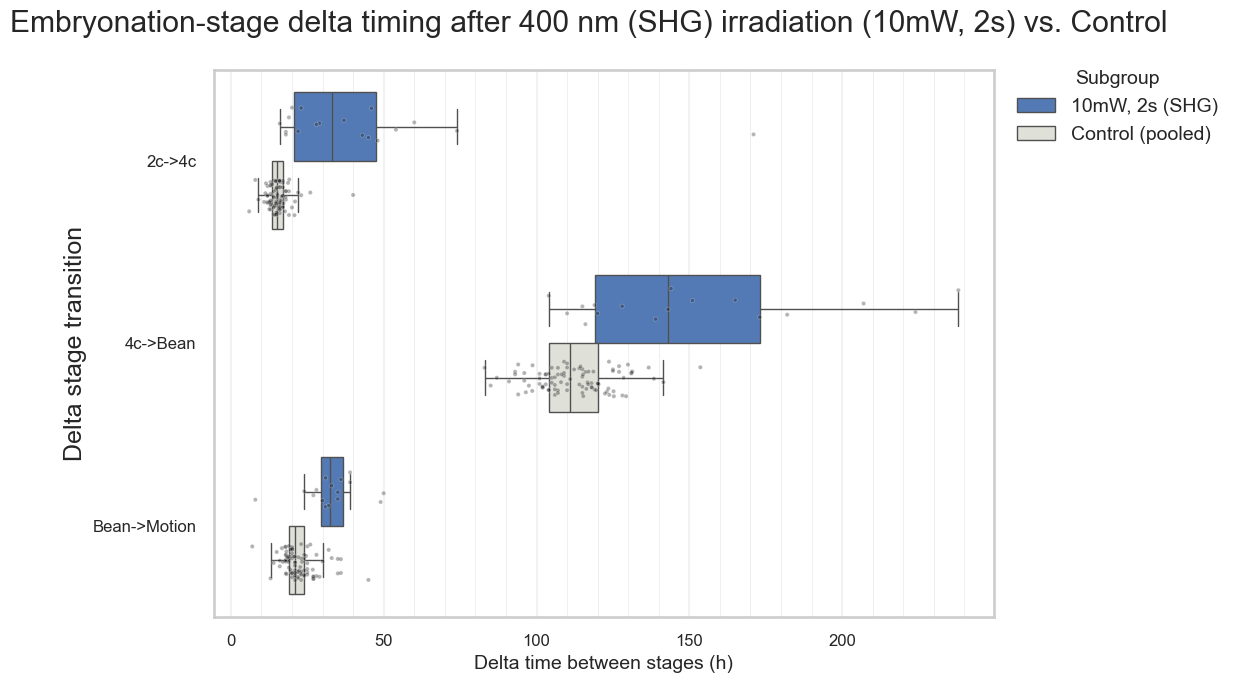

Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/400nm/unembryonated/plots/boxplot_shg_delta_selected_vs_pooled_control.png


In [12]:
# Grouped boxplot with strip overlay comparing delta-stage timing across selected SHG datasets and pooled controls

fig_caption_shg_delta_boxplot = (
    "Figure: Grouped boxplot with strip overlay comparing delta-stage timing across selected SHG datasets and pooled controls. "
    "The x-axis is elapsed time in hours between consecutive stages (delta_h), and the y-axis shows transition stage "
    "(2c->4c, 4c->Bean, Bean->Motion). Boxplots summarize subgroup distributions (median, IQR, whiskers), and jittered "
    "points show individual eggs. The legend identifies selected SHG datasets and pooled controls; pooled controls combine "
    "control dates 2024-03-04, 2024-03-20, and 2025-06-12. Included eggs are restricted to VALID_OUTCOMES (non-degenerated "
    "outcomes defined earlier), with transition-wise sample sizes varying due to missing stage timestamps."
)
print(fig_caption_shg_delta_boxplot)

if "shg_delta_table_df" not in globals():
    raise ValueError("Run the SHG delta table cell first.")

delta_stage_map = {
    "delta_2c_4c": "2c->4c",
    "delta_4c_bean": "4c->Bean",
    "delta_bean_move": "Bean->Motion",
}
delta_stage_order = ["2c->4c", "4c->Bean", "Bean->Motion"]

group_order = selected_shg_labels + ["pooled_control"]

def format_group_label(g: str) -> str:
    if g == "pooled_control":
        return "Control (pooled)"
    if g.startswith("shg_"):
        parts = g.split("_")
        if len(parts) >= 3:
            return f"{parts[1]}, {parts[2]} (SHG)"
    return g.replace("_", " ")

group_display_map = {g: format_group_label(g) for g in group_order}

base_colors = ["#4477c5", "#e0e2d8", "#7f8c8d", "#4e79a7"]
palette = {g: base_colors[i % len(base_colors)] for i, g in enumerate(group_order)}
point_palette = {g: "#000000" if g == "pooled_control" else "#0A0A0A" for g in group_order}

delta_long = (
    shg_delta_table_df.melt(
        id_vars=["egg_uid", "well_id", "group", "duration_label"],
        value_vars=["delta_2c_4c", "delta_4c_bean", "delta_bean_move"],
        var_name="delta_stage",
        value_name="delta_h",
    )
    .dropna(subset=["delta_h"])
    .copy()
)
delta_long["delta_stage"] = delta_long["delta_stage"].map(delta_stage_map)
delta_long["delta_stage"] = pd.Categorical(delta_long["delta_stage"], categories=delta_stage_order, ordered=True)
delta_long["group"] = pd.Categorical(delta_long["group"], categories=group_order, ordered=True)

fig, ax = plt.subplots(figsize=(12, 7.5))
sns.boxplot(
    data=delta_long,
    x="delta_h",
    y="delta_stage",
    hue="group",
    order=delta_stage_order,
    hue_order=group_order,
    palette=palette,
    showfliers=False,
    linewidth=1.0,
    width=0.75,
    ax=ax,
)

sns.stripplot(
    data=delta_long,
    x="delta_h",
    y="delta_stage",
    hue="group",
    order=delta_stage_order,
    hue_order=group_order,
    palette=point_palette,
    dodge=True,
    jitter=0.2,
    size=3,
    alpha=0.3,
    linewidth=0.5,
    edgecolor="white",
    ax=ax,
)

ax.set_title("")
ax.set_ylabel("Delta stage transition", fontsize=18)
ax.set_xlabel("Delta time between stages (h)", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.grid(axis="x", alpha=0.25)
ax.xaxis.set_minor_locator(MultipleLocator(10))
ax.grid(axis="x", which="minor", color="#e0e0e0", linewidth=0.4, alpha=0.9)

handles, labels = ax.get_legend_handles_labels()
seen = set()
uniq_h = []
uniq_l = []
for h, l in zip(handles, labels):
    if l in seen:
        continue
    seen.add(l)
    uniq_h.append(h)
    uniq_l.append(l)

if ax.get_legend() is not None:
    ax.get_legend().remove()

display_labels = [group_display_map.get(l, l) for l in uniq_l]
fig.legend(
    uniq_h,
    display_labels,
    title="Subgroup",
    loc="upper left",
    bbox_to_anchor=(0.85, 0.85),
    frameon=False,
    fontsize=14,
    title_fontsize=14,
    borderaxespad=0.0,
)

fig.suptitle("Embryonation-stage delta timing after 400 nm (SHG) irradiation (10mW, 2s) vs. Control", y=0.92)
plt.tight_layout(rect=[0.04, 0, 0.86, 0.95])
out_png = PLOTS_DIR / "boxplot_shg_delta_selected_vs_pooled_control.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png.resolve()}")


In [13]:
# Significance across selected SHG datasets and pooled control within each delta group

from itertools import combinations

alpha = 0.05
group_order = selected_shg_labels + ["pooled_control"]
delta_group_order = ["delta_2c_4c", "delta_4c_bean", "delta_bean_move"]


def holm_adjust(pvals: np.ndarray) -> np.ndarray:
    m = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty(m, dtype=float)
    running = 0.0
    for rank, idx in enumerate(order):
        candidate = pvals[idx] * (m - rank)
        running = max(running, candidate)
        adj[idx] = min(running, 1.0)
    return adj


def p_to_sig(p: float) -> str:
    if np.isnan(p):
        return "NA"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"

rows = []
for dcol in delta_group_order:
    groups = [
        shg_delta_table_df.loc[shg_delta_table_df["group"] == g, dcol].dropna().to_numpy(dtype=float)
        for g in group_order
    ]
    sizes = {g: len(arr) for g, arr in zip(group_order, groups)}

    normality_p = {}
    all_groups_normal = True
    for g, arr in zip(group_order, groups):
        if len(arr) < 3:
            normality_p[g] = np.nan
            all_groups_normal = False
            continue
        p_norm = float(stats.shapiro(arr).pvalue)
        normality_p[g] = p_norm
        if p_norm < alpha:
            all_groups_normal = False

    if any(len(arr) == 0 for arr in groups):
        omnibus_test = "NA"
        omnibus_p = np.nan
        pair_method = "NA"
    elif all_groups_normal:
        omnibus_test = "ANOVA"
        omnibus_p = float(stats.f_oneway(*groups).pvalue)
        pair_method = "Welch t-test"
    else:
        omnibus_test = "Kruskal-Wallis"
        omnibus_p = float(stats.kruskal(*groups).pvalue)
        pair_method = "Mann-Whitney U"

    pair_idxs = list(combinations(range(len(group_order)), 2))
    raw_ps = []
    raw_stats = []
    pair_names = []
    for i, j in pair_idxs:
        g1, g2 = groups[i], groups[j]
        pair_names.append(f"{group_order[i]} vs {group_order[j]}")
        if len(g1) == 0 or len(g2) == 0:
            raw_stats.append(np.nan)
            raw_ps.append(np.nan)
            continue
        if pair_method == "Welch t-test":
            tst = stats.ttest_ind(g1, g2, equal_var=False, nan_policy="omit")
            raw_stats.append(float(tst.statistic))
            raw_ps.append(float(tst.pvalue))
        elif pair_method == "Mann-Whitney U":
            mw = stats.mannwhitneyu(g1, g2, alternative="two-sided")
            raw_stats.append(float(mw.statistic))
            raw_ps.append(float(mw.pvalue))
        else:
            raw_stats.append(np.nan)
            raw_ps.append(np.nan)

    raw_ps_arr = np.array(raw_ps, dtype=float)
    valid = np.isfinite(raw_ps_arr)
    adj = np.full_like(raw_ps_arr, np.nan)
    if valid.any():
        adj[valid] = holm_adjust(raw_ps_arr[valid])

    for comp, st, p_raw, p_adj in zip(pair_names, raw_stats, raw_ps, adj):
        row = {
            "delta_group": dcol,
            "omnibus_test": omnibus_test,
            "omnibus_p": omnibus_p,
            "pairwise_test": pair_method,
            "comparison": comp,
            "statistic": st,
            "p_raw": p_raw,
            "p_holm": p_adj,
            "significant_0.05": bool(np.isfinite(p_adj) and p_adj < alpha),
            "sig": p_to_sig(p_adj),
        }
        for g in group_order:
            row[f"n_{g}"] = sizes.get(g, 0)
            row[f"normality_p_{g}"] = normality_p.get(g, np.nan)
        rows.append(row)

shg_delta_stats_df = pd.DataFrame(rows).sort_values(["delta_group", "comparison"]).reset_index(drop=True)
display(shg_delta_stats_df)

out_csv = TABLES_DIR / "shg_delta_significance_selected_vs_pooled_control.csv"
shg_delta_stats_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")


,delta_group,omnibus_test,omnibus_p,pairwise_test,comparison,statistic,p_raw,p_holm,significant_0.05,sig,n_shg_10mW_2s,normality_p_shg_10mW_2s,n_pooled_control,normality_p_pooled_control
0,delta_2c_4c,Kruskal-Wallis,1.469221e-09,Mann-Whitney U,shg_10mW_2s vs pooled_control,1591.500000,1.506204e-09,1.506204e-09,True,***,18,0.000036,93,2.395967e-10
1,delta_4c_bean,ANOVA,1.576438e-11,Welch t-test,shg_10mW_2s vs pooled_control,3.923908,1.139207e-03,1.139207e-03,True,**,17,0.067318,93,7.694534e-01
2,delta_bean_move,Kruskal-Wallis,1.714891e-06,Mann-Whitney U,shg_10mW_2s vs pooled_control,1302.000000,1.751868e-06,1.751868e-06,True,***,16,0.174948,93,3.809887e-06


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/400nm/unembryonated/tables/shg_delta_significance_selected_vs_pooled_control.csv


In [14]:
# Post-hoc table for significant SHG delta comparisons (from previous cell)

if "shg_delta_stats_df" not in globals():
    raise ValueError("Run the SHG delta significance cell first.")

shg_delta_posthoc_sig_df = shg_delta_stats_df[shg_delta_stats_df["significant_0.05"]].copy()
shg_delta_posthoc_sig_df = shg_delta_posthoc_sig_df.sort_values(["delta_group", "comparison"]).reset_index(drop=True)

display(shg_delta_posthoc_sig_df)

out_csv = TABLES_DIR / "shg_delta_posthoc_significant_rows.csv"
shg_delta_posthoc_sig_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")


,delta_group,omnibus_test,omnibus_p,pairwise_test,comparison,statistic,p_raw,p_holm,significant_0.05,sig,n_shg_10mW_2s,normality_p_shg_10mW_2s,n_pooled_control,normality_p_pooled_control
0,delta_2c_4c,Kruskal-Wallis,1.469221e-09,Mann-Whitney U,shg_10mW_2s vs pooled_control,1591.500000,1.506204e-09,1.506204e-09,True,***,18,0.000036,93,2.395967e-10
1,delta_4c_bean,ANOVA,1.576438e-11,Welch t-test,shg_10mW_2s vs pooled_control,3.923908,1.139207e-03,1.139207e-03,True,**,17,0.067318,93,7.694534e-01
2,delta_bean_move,Kruskal-Wallis,1.714891e-06,Mann-Whitney U,shg_10mW_2s vs pooled_control,1302.000000,1.751868e-06,1.751868e-06,True,***,16,0.174948,93,3.809887e-06


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/400nm/unembryonated/tables/shg_delta_posthoc_significant_rows.csv


In [15]:
# Time differences (hours) for significant SHG delta post-hoc comparisons

if "shg_delta_posthoc_sig_df" not in globals():
    raise ValueError("Run the SHG delta significant post-hoc table cell first.")

rows = []
for _, r in shg_delta_posthoc_sig_df.iterrows():
    dcol = r["delta_group"]
    g1_name, g2_name = r["comparison"].split(" vs ")

    g1 = shg_delta_table_df[shg_delta_table_df["group"] == g1_name][dcol].dropna().to_numpy(dtype=float)
    g2 = shg_delta_table_df[shg_delta_table_df["group"] == g2_name][dcol].dropna().to_numpy(dtype=float)
    if len(g1) == 0 or len(g2) == 0:
        continue

    mean_g1 = float(np.mean(g1))
    mean_g2 = float(np.mean(g2))
    med_g1 = float(np.median(g1))
    med_g2 = float(np.median(g2))
    sd_g1 = float(np.std(g1, ddof=1)) if len(g1) > 1 else np.nan
    sd_g2 = float(np.std(g2, ddof=1)) if len(g2) > 1 else np.nan

    rows.append(
        {
            "delta_group": dcol,
            "comparison": r["comparison"],
            "n_group1": int(len(g1)),
            "n_group2": int(len(g2)),
            "median_group1_h": med_g1,
            "median_group2_h": med_g2,
            "median_diff_h_(g2-g1)": med_g2 - med_g1,
            "mean_group1_h": mean_g1,
            "mean_group2_h": mean_g2,
            "mean_diff_h_(g2-g1)": mean_g2 - mean_g1,
            "sd_group1_h": sd_g1,
            "sd_group2_h": sd_g2,
            "sd_diff_indep_h": np.sqrt(sd_g1 ** 2 + sd_g2 ** 2) if np.isfinite(sd_g1) and np.isfinite(sd_g2) else np.nan,
            "p_holm": r["p_holm"],
            "sig": r["sig"],
        }
    )

shg_delta_sig_diffs_df = pd.DataFrame(rows).sort_values(["delta_group", "comparison"]).reset_index(drop=True)
display(shg_delta_sig_diffs_df)

out_csv = TABLES_DIR / "shg_delta_significant_time_differences.csv"
shg_delta_sig_diffs_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")


,delta_group,comparison,n_group1,n_group2,median_group1_h,median_group2_h,median_diff_h_(g2-g1),mean_group1_h,mean_group2_h,mean_diff_h_(g2-g1),sd_group1_h,sd_group2_h,sd_diff_indep_h,p_holm,sig
0,delta_2c_4c,shg_10mW_2s vs pooled_control,18,93,33.0,15.0,-18.0,42.833333,15.533333,-27.300000,36.116234,3.902071,36.326416,1.506204e-09,***
1,delta_4c_bean,shg_10mW_2s vs pooled_control,17,93,143.0,111.0,-32.0,151.647059,112.306452,-39.340607,40.964834,12.957596,42.965299,1.139207e-03,**
2,delta_bean_move,shg_10mW_2s vs pooled_control,16,93,32.5,21.0,-11.5,32.937500,22.247312,-10.690188,9.726039,5.451976,11.149882,1.751868e-06,***


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/400nm/unembryonated/tables/shg_delta_significant_time_differences.csv
